# Magnetic Data Analysis

This notebook reads the extracted magnetic survey data within the ZL boundary and creates visualizations of the magnetic field data.

In [1]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the CSV File
df = pd.read_csv('data/SLMAG_ZL_boundary.csv')

print(f"Loaded {len(df):,} rows from SLMAG_ZL_boundary.csv")
print(f"Columns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")

Loaded 690,326 rows from SLMAG_ZL_boundary.csv
Columns: ['aircraft', 'date', 'flight', 'line_number', 'line', 'line_part', 'fiducial', 'time_utc', 'gps_x_raw', 'gps_y_raw', 'gps_z_raw', 'gps_x_final', 'gps_y_final', 'gps_z_final', 'x_nad83', 'y_nad83', 'lon_nad83', 'lat_nad83', 'radar1_raw', 'radar2_raw', 'radar_final', 'dem', 'mag_base1_raw', 'mag_base2_raw', 'mag_base1', 'mag_base2', 'fluxgate_x', 'fluxgate_y', 'fluxgate_z', 'mag_raw_left', 'mag_raw_right', 'mag_raw_tail', 'mag_comp_left', 'mag_comp_right', 'mag_comp_tail', 'mag_lag_left', 'mag_lag_right', 'mag_lag_tail', 'mag_diurn1_tail', 'mag_diurn2_tail', 'igrf', 'mag_miclev_tail', 'mag_lev_tail', 'mag_final_tail', 'mag_gsclev_tail', 'grad_raw_lat', 'grad_comp_lat', 'grad_lag_lat', 'grad_rot_lat', 'grad_lev_lat', 'grad_raw_lon', 'grad_comp_lon', 'grad_lag_lon', 'grad_rot_lon', 'grad_lev_lon', 'pitch', 'roll', 'yaw', 'azimuth', 'index_right']

Data types:
aircraft            object
date                object
flight               i

In [3]:
# Prepare the Data
# Select relevant columns for magnetic data visualization
magnetic_columns = ['mag_final_tail', 'mag_lev_tail', 'mag_miclev_tail', 'mag_gsclev_tail']
location_columns = ['lon_nad83', 'lat_nad83', 'x_nad83', 'y_nad83']

print("Magnetic data columns available:")
for col in magnetic_columns:
    if col in df.columns:
        non_null = df[col].notna().sum()
        print(f"{col}: {non_null:,} non-null values")
        print(f"  Range: {df[col].min():.2f} to {df[col].max():.2f}")
        print(f"  Mean: {df[col].mean():.2f}")
    else:
        print(f"{col}: Not found")
    print()

# Choose the primary magnetic field column for plotting
mag_col = 'mag_final_tail'  # Final processed magnetic data

# Remove any rows with missing magnetic data or coordinates
df_clean = df.dropna(subset=[mag_col, 'lon_nad83', 'lat_nad83'])

print(f"After cleaning: {len(df_clean):,} rows")
print(f"Removed {len(df) - len(df_clean):,} rows with missing data")

Magnetic data columns available:
mag_final_tail: 690,326 non-null values
  Range: -490.75 to 2681.20
  Mean: 118.38

mag_lev_tail: 690,326 non-null values
  Range: 56614.28 to 59769.47
  Mean: 57202.94

mag_miclev_tail: 690,326 non-null values
  Range: 56613.86 to 59769.47
  Mean: 57202.99

mag_gsclev_tail: 690,326 non-null values
  Range: -528.24 to 2641.68
  Mean: 78.41

After cleaning: 690,326 rows
Removed 0 rows with missing data


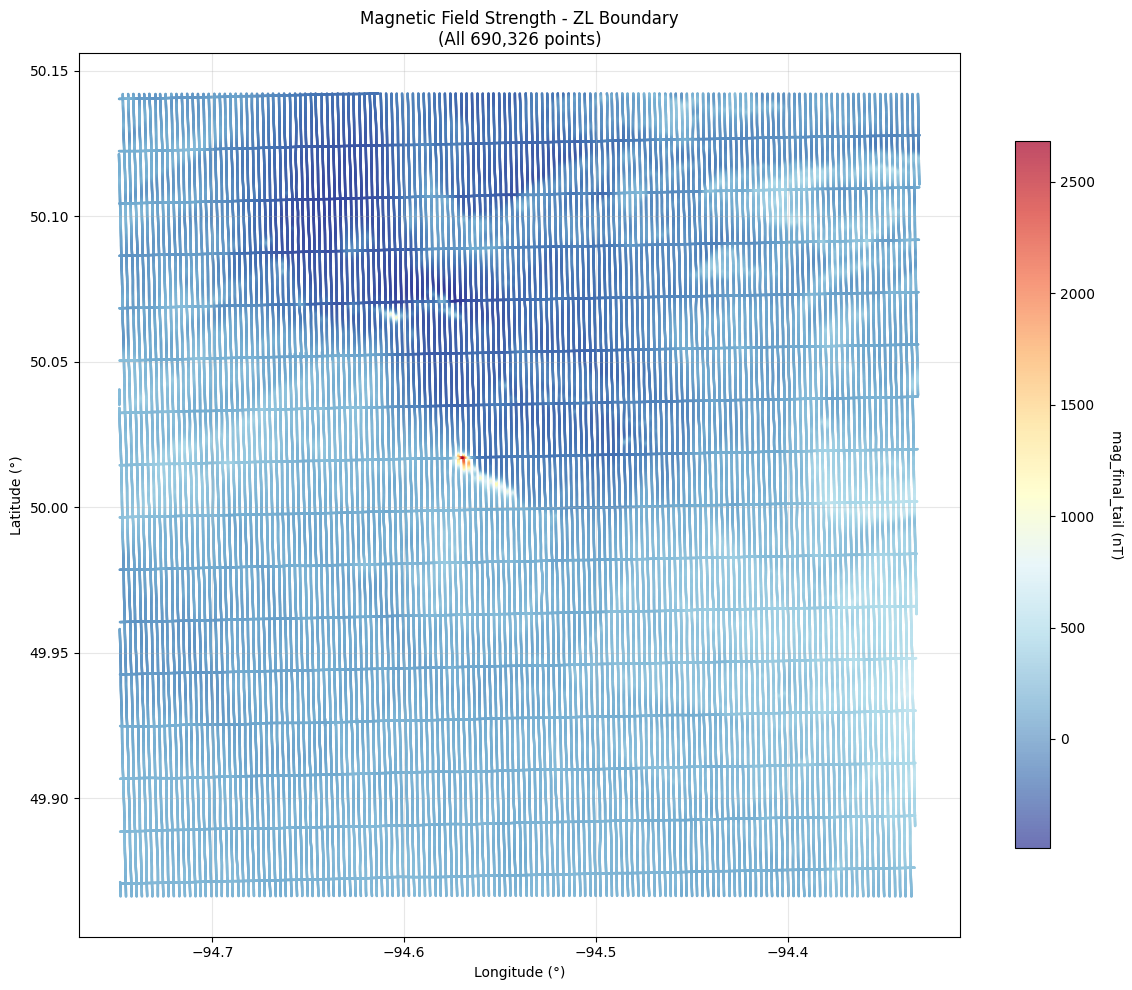

Plot shows all 690,326 points
Magnetic field range: -491 to 2681 nT
Mean magnetic field: 118 nT


In [6]:
# Create Scatter Plot
# Plot all points (may be slow with 690k+ points)

# Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 10))

# Scatter plot with color mapping for magnetic field strength
scatter = ax.scatter(df_clean['lon_nad83'], df_clean['lat_nad83'],
                    c=df_clean[mag_col], cmap='RdYlBu_r', s=0.5, alpha=0.7)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label(f'{mag_col} (nT)', rotation=270, labelpad=20)

# Set labels and title
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title(f'Magnetic Field Strength - ZL Boundary\n(All {len(df_clean):,} points)')

# Add grid
ax.grid(True, alpha=0.3)

# Format tick labels
ax.ticklabel_format(useOffset=False)

plt.tight_layout()
plt.show()

print(f"Plot shows all {len(df_clean):,} points")
print(f"Magnetic field range: {df_clean[mag_col].min():.0f} to {df_clean[mag_col].max():.0f} nT")
print(f"Mean magnetic field: {df_clean[mag_col].mean():.0f} nT")

In [5]:
# Summary Statistics
print("Summary of Magnetic Data:")
print(f"Total data points: {len(df_clean):,}")
print(f"Magnetic field ({mag_col}):")
print(f"  Min: {df_clean[mag_col].min():.0f} nT")
print(f"  Max: {df_clean[mag_col].max():.0f} nT")
print(f"  Mean: {df_clean[mag_col].mean():.0f} nT")
print(f"  Std Dev: {df_clean[mag_col].std():.0f} nT")

# Aircraft distribution
if 'aircraft' in df_clean.columns:
    print(f"\nAircraft distribution:")
    print(df_clean['aircraft'].value_counts())

Summary of Magnetic Data:
Total data points: 690,326
Magnetic field (mag_final_tail):
  Min: -491 nT
  Max: 2681 nT
  Mean: 118 nT
  Std Dev: 189 nT

Aircraft distribution:
aircraft
LDX    644706
JBB     45620
Name: count, dtype: int64


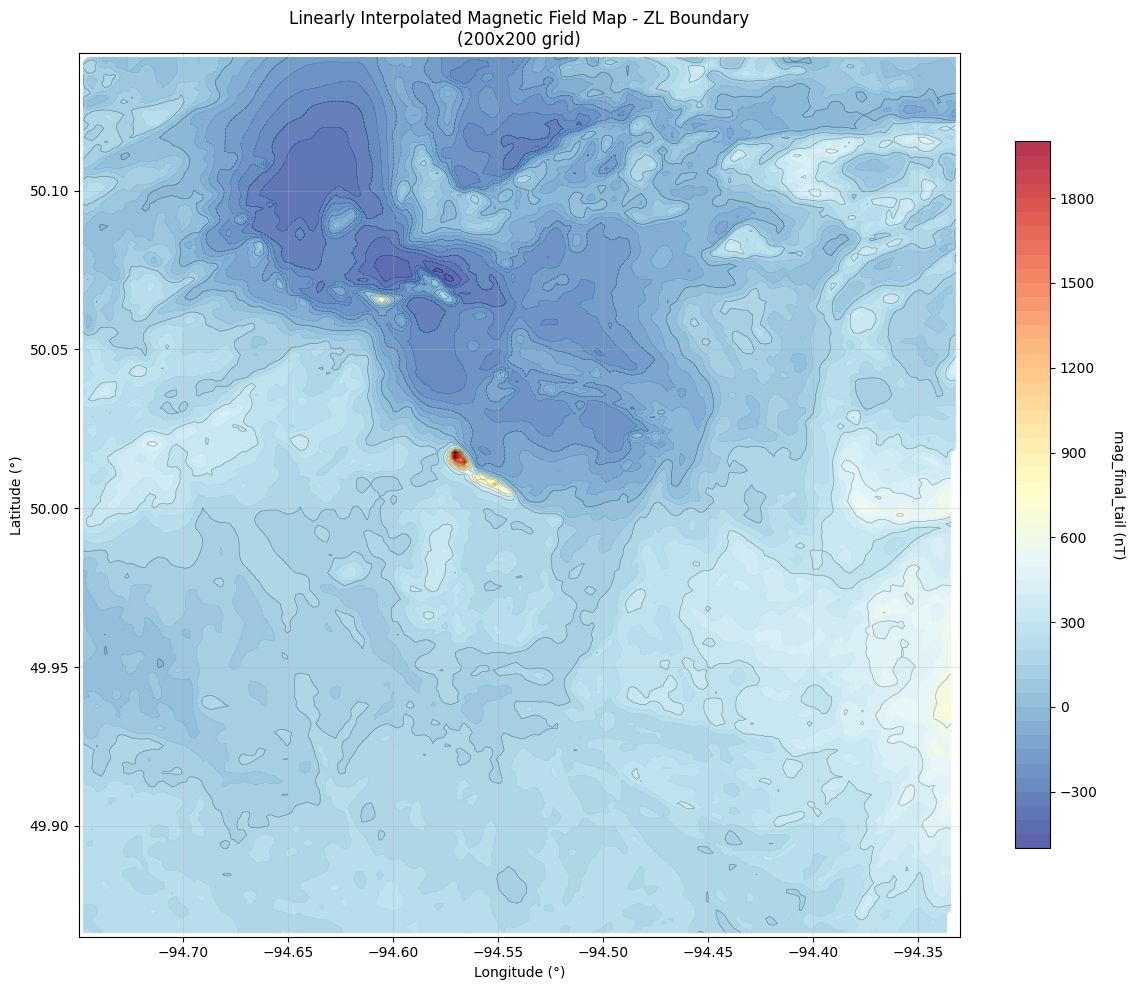

Interpolated map created with 200x200 = 40,000 grid points
Original data points: 690,326
Magnetic field range: -491 to 2681 nT
Interpolation method: Linear


In [7]:
# Create Linearly Interpolated Map
from scipy.interpolate import griddata
import numpy as np

# Define grid resolution (adjust as needed)
grid_resolution = 200  # Number of points in each dimension

# Create grid coordinates
lon_min, lon_max = df_clean['lon_nad83'].min(), df_clean['lon_nad83'].max()
lat_min, lat_max = df_clean['lat_nad83'].min(), df_clean['lat_nad83'].max()

# Add small buffer to grid bounds
buffer = 0.001
lon_grid = np.linspace(lon_min - buffer, lon_max + buffer, grid_resolution)
lat_grid = np.linspace(lat_min - buffer, lat_max + buffer, grid_resolution)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Perform linear interpolation
points = df_clean[['lon_nad83', 'lat_nad83']].values
values = df_clean[mag_col].values

mag_interpolated = griddata(points, values, (lon_mesh, lat_mesh), method='linear')

# Create the interpolated map
fig, ax = plt.subplots(figsize=(12, 10))

# Plot filled contours
contour = ax.contourf(lon_mesh, lat_mesh, mag_interpolated, levels=50, cmap='RdYlBu_r', alpha=0.8)

# Add contour lines
contour_lines = ax.contour(lon_mesh, lat_mesh, mag_interpolated, levels=20, colors='black', linewidths=0.5, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(contour, ax=ax, shrink=0.8)
cbar.set_label(f'{mag_col} (nT)', rotation=270, labelpad=20)

# Set labels and title
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title(f'Linearly Interpolated Magnetic Field Map - ZL Boundary\n({grid_resolution}x{grid_resolution} grid)')

# Add grid
ax.grid(True, alpha=0.3)

# Format tick labels
ax.ticklabel_format(useOffset=False)

plt.tight_layout()
plt.show()

print(f"Interpolated map created with {grid_resolution}x{grid_resolution} = {grid_resolution**2:,} grid points")
print(f"Original data points: {len(df_clean):,}")
print(f"Magnetic field range: {df_clean[mag_col].min():.0f} to {df_clean[mag_col].max():.0f} nT")
print(f"Interpolation method: Linear")